# Pipeline Consolidado de Classificação de Incidentes (Versão Final)
Este fluxo organiza as fases de limpeza, preparação, treinamento e análise de forma sequencial.

In [22]:
!pip install -q mlflow dagshub
!pip install gensim

In [4]:
import pandas as pd
import numpy as np
import re
import nltk
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

nltk.download('stopwords')
print("Setup concluído.")

Setup concluído.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## 1. Carga e Limpeza de Dados

In [5]:
# Carga
df_raw = pd.read_csv('incidente.csv', sep=';')

# Limpeza inicial: Remover nulos e classes indesejadas identificadas
df_clean = df_raw.dropna(subset=['tipo_incidente', 'detalhe_incidente']).copy()
df_clean = df_clean[df_clean['tipo_incidente'] != 'Corresp']

# Padronização de Texto Avançada
stop_words_pt = set(stopwords.words('portuguese'))
custom_stopwords = {'bom', 'dia', 'tarde', 'noite', 'favor', 'obrigado', 'solicito', 'solicitação', 'gentileza', 'verificar', 'analisar'}
stop_words_pt.update(custom_stopwords)

def limpar_texto(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zÀ-ÿ\s]', ' ', text)
    tokens = [t for t in text.split() if t not in stop_words_pt and len(t) > 2]
    return " ".join(tokens)

print("Limpando descrições...")
df_clean['detalhe_limpo'] = df_clean['detalhe_incidente'].apply(limpar_texto)
display(df_clean.head(3))

Limpando descrições...


,detalhe_incidente,tipo_incidente,detalhe_limpo
0,resetar senha sumir vario função sap sap,Erro,resetar senha sumir vario função sap sap
1,samippp inoperante sistema samippp,Corretiva,samippp inoperante sistema samippp
2,aprovação pedido parar gestão anterior myrian ...,Preventiva,aprovação pedido parar gestão anterior myrian ...


## 2. Padronização de Categorias (Estratégia V4)
Remoção de classes raras e agrupamento de Dúvida/Projeto.

## 3. Vetorização e Divisão

In [6]:
# 1. Padronização rigorosa: Remover espaços e converter para Capitalize
df_clean['tipo_incidente'] = df_clean['tipo_incidente'].astype(str).str.strip().str.capitalize()

# 2. Mapeamento de consolidação (Garante que variações virem a mesma classe)
# Agrupamos Dúvida e Projeto em Avaliação_Técnica e removemos variações de case
mapping_v4 = {
    'Dúvida': 'Avaliação_Técnica',
    'Projeto': 'Avaliação_Técnica',
    'Melhoria': 'Melhorias',
    'Melhores': 'Melhorias'
}

df_final = df_clean.copy()
df_final['tipo_incidente'] = df_final['tipo_incidente'].replace(mapping_v4)

# 3. Remover classes raras e resíduos de limpeza identificados no log anterior
classes_para_remover = ['Em estudo', 'Preventiva', 'Corresp', 'Nan']
df_final = df_final[~df_final['tipo_incidente'].isin(classes_para_remover)].copy()

# 4. Encoding final
le_final = LabelEncoder()
df_final['target'] = le_final.fit_transform(df_final['tipo_incidente'])

print("Distribuição Final de Classes (v4 Consolidada):")
print(df_final['tipo_incidente'].value_counts())
print(f"\nTotal de classes únicas: {len(le_final.classes_)}")
print(f"Classes: {list(le_final.classes_)}")

Distribuição Final de Classes (v4 Consolidada):
tipo_incidente
Corretiva              865
Melhorias              814
Erro                   394
Avaliação_Técnica      216
Nova instalação        172
Adequação de layout     82
Retorno                 34
Name: count, dtype: int64

Total de classes únicas: 7
Classes: ['Adequação de layout', 'Avaliação_Técnica', 'Corretiva', 'Erro', 'Melhorias', 'Nova instalação', 'Retorno']


In [7]:
X = df_final['detalhe_limpo']
y = df_final['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

tfidf_final = TfidfVectorizer(max_features=8000, ngram_range=(1, 3), min_df=3, sublinear_tf=True)
X_train_tfidf = tfidf_final.fit_transform(X_train)
X_test_tfidf = tfidf_final.transform(X_test)

print(f"Vetorização concluída: {X_train_tfidf.shape[1]} features geradas.")

Vetorização concluída: 3747 features geradas.


## 4. Treinamento e Balanceamento

In [8]:
# Balanceamento
smote = SMOTE(random_state=42, k_neighbors=1)
X_res, y_res = smote.fit_resample(X_train_tfidf, y_train)

# Modelo
modelo_final = LogisticRegression(max_iter=1000, class_weight='balanced')
modelo_final.fit(X_res, y_res)

print("Modelo treinado com sucesso.")

Modelo treinado com sucesso.


## 5. Avaliação e Análise

--- RELATÓRIO DE PERFORMANCE ---
                     precision    recall  f1-score   support

Adequação de layout       0.53      0.56      0.55        16
  Avaliação_Técnica       0.37      0.33      0.35        43
          Corretiva       0.70      0.55      0.61       173
               Erro       0.49      0.67      0.57        79
          Melhorias       0.62      0.61      0.62       163
    Nova instalação       0.50      0.71      0.59        35
            Retorno       0.80      0.57      0.67         7

           accuracy                           0.58       516
          macro avg       0.57      0.57      0.56       516
       weighted avg       0.60      0.58      0.58       516



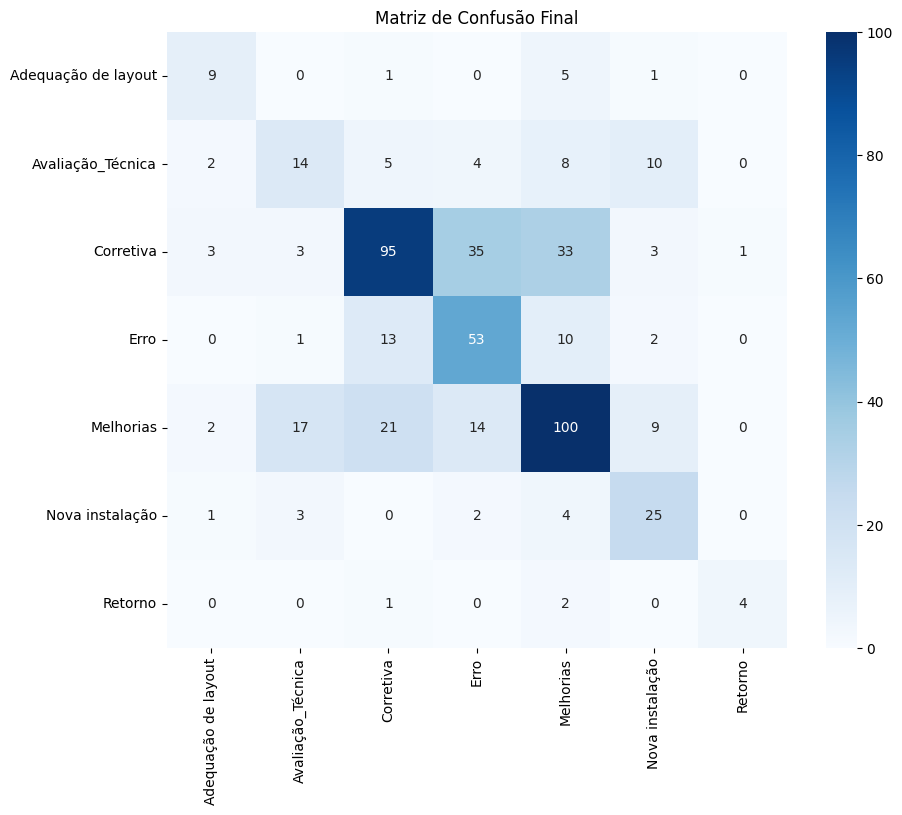

In [9]:
y_pred = modelo_final.predict(X_test_tfidf)

print("--- RELATÓRIO DE PERFORMANCE ---")
print(classification_report(y_test, y_pred, target_names=le_final.classes_))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=le_final.classes_, yticklabels=le_final.classes_)
plt.title('Matriz de Confusão Final')
plt.show()

```markdown
# ==================================================
# VERSÃO FINAL CONSOLIDADA (PRODUÇÃO)
# ==================================================
Este bloco contém o pipeline otimizado (Estratégia V4), pronto para uso.
```

In [10]:
import pandas as pd
import numpy as np
import re
import nltk
import joblib
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup e Carga
nltk.download('stopwords', quiet=True)
df_raw = pd.read_csv('incidente.csv', sep=';')

# 2. Limpeza de Texto com Stopwords Expandidas
stop_words_pt = set(stopwords.words('portuguese'))
# Adicionando termos ambíguos identificados na análise de erros
custom_stopwords = {
    'bom', 'dia', 'tarde', 'noite', 'favor', 'obrigado', 'solicito', 'solicitação',
    'gentileza', 'verificar', 'analisar', 'sisap', 'sap', 'linha', 'posto',
    'acesso', 'sistema', 'dado', 'problema', 'usuário', 'através'
}
stop_words_pt.update(custom_stopwords)

def limpar_texto(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zÀ-ÿ\s]', ' ', text)
    tokens = [t for t in text.split() if t not in stop_words_pt and len(t) > 2]
    return " ".join(tokens)

# 3. Processamento e Padronização V4
df_proc = df_raw.dropna(subset=['tipo_incidente', 'detalhe_incidente']).copy()
df_proc['tipo_incidente'] = df_proc['tipo_incidente'].astype(str).str.strip().str.capitalize()

mapping_v4 = {
    'Dúvida': 'Avaliação_Técnica',
    'Projeto': 'Avaliação_Técnica',
    'Melhoria': 'Melhorias',
    'Melhores': 'Melhorias'
}
df_proc['tipo_incidente'] = df_proc['tipo_incidente'].replace(mapping_v4)

classes_remover = ['Em estudo', 'Preventiva', 'Corresp', 'Nan']
df_proc = df_proc[~df_proc['tipo_incidente'].isin(classes_remover)].copy()

df_proc['detalhe_limpo'] = df_proc['detalhe_incidente'].apply(limpar_texto)

# 4. Preparação de Dados
le = LabelEncoder()
y = le.fit_transform(df_proc['tipo_incidente'])
X = df_proc['detalhe_limpo']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Vetorização e Balanceamento
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1, 3), min_df=3, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

smote = SMOTE(random_state=42, k_neighbors=1)
X_res, y_res = smote.fit_resample(X_train_tfidf, y_train)

# 6. Treinamento e Exportação
modelo = LogisticRegression(max_iter=1000, class_weight='balanced')
modelo.fit(X_res, y_res)

# Salvar Artefatos
joblib.dump(modelo, 'modelo_final_v4.pkl')
joblib.dump(tfidf, 'vectorizer_final_v4.pkl')
joblib.dump(le, 'label_encoder_final_v4.pkl')

print(f'Pipeline Concluído com Stopwords Expandidas. Classes: {list(le.classes_)}')

Pipeline Concluído com Stopwords Expandidas. Classes: ['Adequação de layout', 'Avaliação_Técnica', 'Corretiva', 'Erro', 'Melhorias', 'Nova instalação', 'Retorno']


                     precision    recall  f1-score   support

Adequação de layout       0.50      0.56      0.53        16
  Avaliação_Técnica       0.28      0.33      0.30        43
          Corretiva       0.71      0.55      0.62       173
               Erro       0.49      0.65      0.55        79
          Melhorias       0.65      0.61      0.63       163
    Nova instalação       0.52      0.74      0.61        35
            Retorno       1.00      0.57      0.73         7

           accuracy                           0.58       516
          macro avg       0.59      0.57      0.57       516
       weighted avg       0.60      0.58      0.58       516



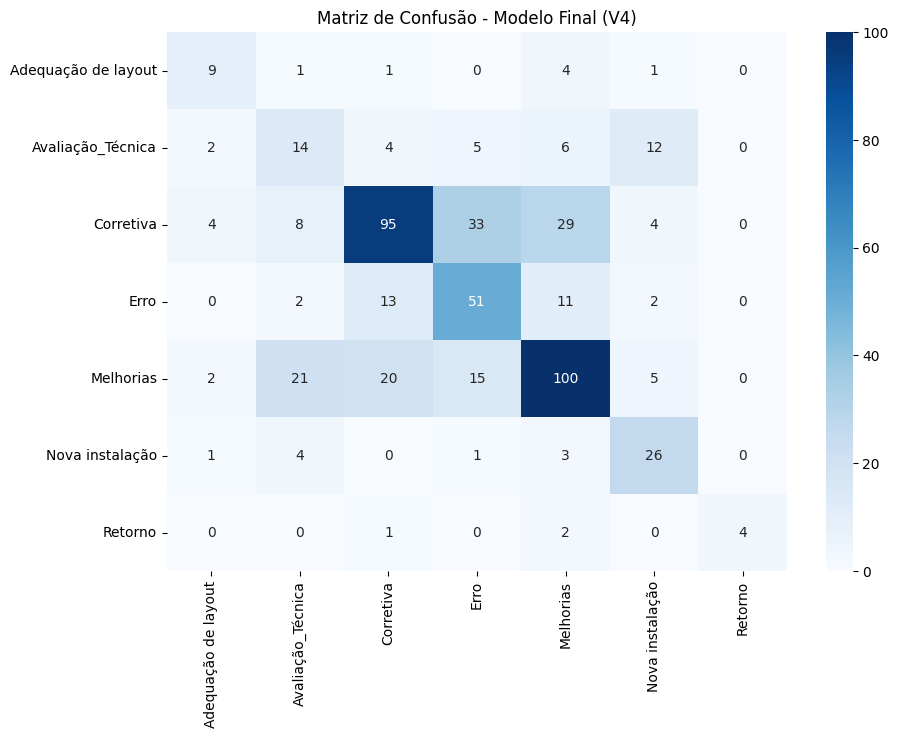

In [11]:
# 7. Avaliação Final
y_pred = modelo.predict(X_test_tfidf)
print(classification_report(y_test, y_pred, target_names=le.classes_))

plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='g', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão - Modelo Final (V4)')
plt.show()

In [12]:
print("\n--- Análise Detalhada de Erros de Classificação (Versão Final V4) ---")

# Ajuste: Usando as variáveis do Pipeline Final (V4) que possuem o mesmo comprimento
error_analysis_df = pd.DataFrame({
    'detalhe_incidente': X_test.values, # Texto original do teste
    'true_label_encoded': y_test.values if hasattr(y_test, 'values') else y_test,
    'predicted_label_encoded': y_pred
})

# Adicionar as classes textuais para facilitar a análise
error_analysis_df['true_class'] = le.inverse_transform(error_analysis_df['true_label_encoded'])
error_analysis_df['predicted_class'] = le.inverse_transform(error_analysis_df['predicted_label_encoded'])

# Filtrar apenas as instâncias mal classificadas
misclassified_df = error_analysis_df[error_analysis_df['true_label_encoded'] != error_analysis_df['predicted_label_encoded']]

print(f"Total de amostras no teste: {len(error_analysis_df)}")
print(f"Total de amostras mal classificadas: {len(misclassified_df)}")

# Mostrar os principais tipos de erros
print("\nPrincipais tipos de erros (Real -> Previsto):")
print(misclassified_df.groupby(['true_class', 'predicted_class']).size().nlargest(10))

def show_misclassified_examples(true_class_name, predicted_class_name, num_examples=3):
    print(f"\n--- Exemplos de '{true_class_name}' previstos como '{predicted_class_name}' ---")
    examples = misclassified_df[
        (misclassified_df['true_class'] == true_class_name) &
        (misclassified_df['predicted_class'] == predicted_class_name)
    ]['detalhe_incidente'].head(num_examples)
    for ex in examples:
        print(f"- {ex}")

# Exemplos práticos
show_misclassified_examples('Corretiva', 'Melhorias')
show_misclassified_examples('Melhorias', 'Corretiva')


--- Análise Detalhada de Erros de Classificação (Versão Final V4) ---
Total de amostras no teste: 516
Total de amostras mal classificadas: 217

Principais tipos de erros (Real -> Previsto):
true_class         predicted_class  
Corretiva          Erro                 33
                   Melhorias            29
Melhorias          Avaliação_Técnica    21
                   Corretiva            20
                   Erro                 15
Erro               Corretiva            13
Avaliação_Técnica  Nova instalação      12
Erro               Melhorias            11
Corretiva          Avaliação_Técnica     8
Avaliação_Técnica  Melhorias             6
dtype: int64

--- Exemplos de 'Corretiva' previstos como 'Melhorias' ---
- solicitar liberação preenchimento planilha maquina mns pequeno aprendiz natalyepc indústria norma controle entrega epis desbloqueio planilha
- embalagem evaporadora arcon permitir ler apontar produto kit acessório ler apontar origem proposta caso número série kit ace

### Análise de Palavras Mais Frequentes nas Instâncias Mal Classificadas

Vamos extrair as palavras mais comuns nos textos que foram mal classificados. Isso pode nos dar pistas sobre termos ambíguos ou contextos que o modelo está tendo dificuldade em interpretar corretamente.


--- Análise das palavras mais frequentes nas instâncias mal classificadas ---
20 palavras mais frequentes nas instâncias mal classificadas:
- erro: 30
- arcon: 27
- entrada: 24
- novo: 23
- ajustir: 21
- tela: 21
- item: 21
- lote: 20
- cadastro: 20
- valor: 20
- realizar: 19
- modelo: 18
- quantidade: 18
- anexo: 17
- produto: 17
- etiqueta: 17
- painel: 17
- registro: 17
- fiscal: 17
- leitura: 16


/tmp/ipykernel_3095/1566245156.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequência', y='Palavra', data=words_df, palette='viridis')


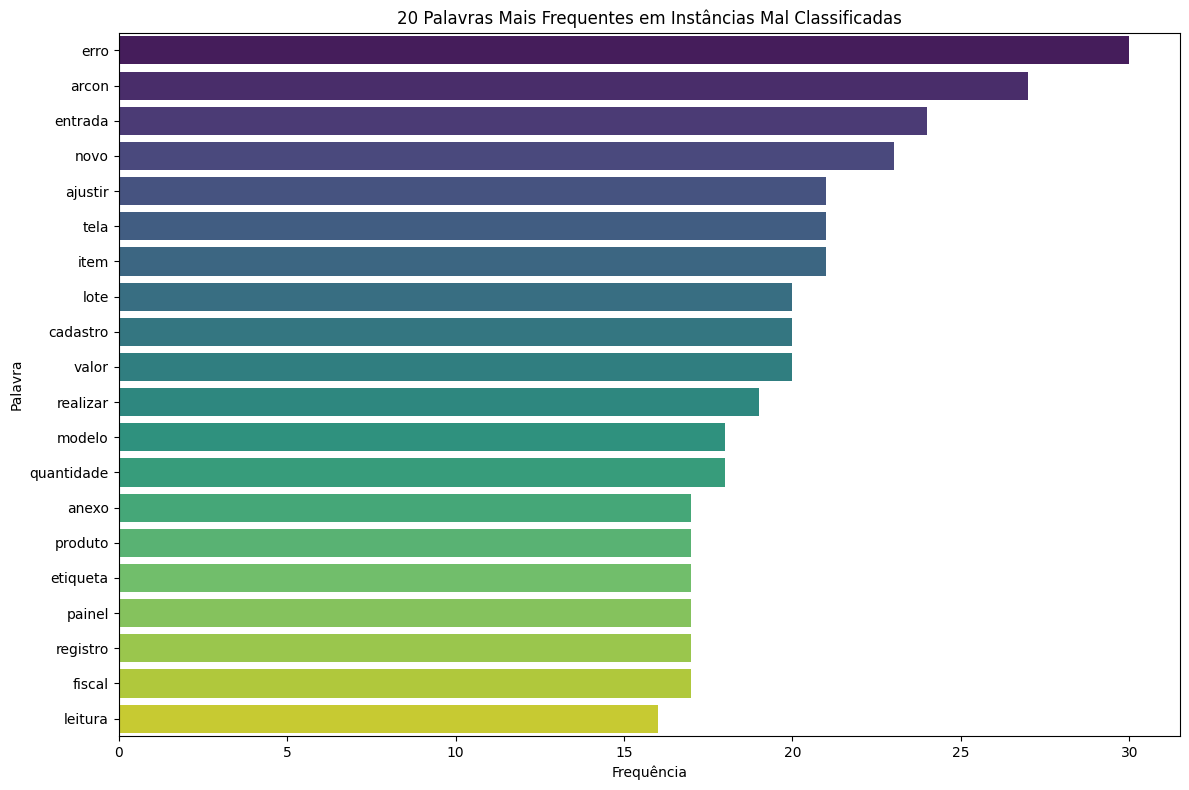

In [13]:
from collections import Counter
import re

print("\n--- Análise das palavras mais frequentes nas instâncias mal classificadas ---")

# Juntar todos os textos das instâncias mal classificadas
all_misclassified_text = ' '.join(misclassified_df['detalhe_incidente'].dropna().tolist())

# Tokenizar as palavras (converter para minúsculas e remover caracteres não alfabéticos)
words = re.findall(r'\b[a-z]+\b', all_misclassified_text.lower())

# Remover stopwords (palavras comuns que não agregam muito significado)
# Você pode expandir esta lista de stopwords conforme necessário para português
stopwords_pt = set([
    'de', 'a', 'o', 'que', 'e', 'do', 'da', 'em', 'um', 'para', 'é', 'com', 'não', 'uma', 'os', 'no', 'se',
    'na', 'por', 'mais', 'as', 'dos', 'das', 'ao', 'à', 'ele', 'ela', 'dele', 'dela', 'nele', 'nela', 'isso',
    'este', 'esta', 'esse', 'essa', 'disso', 'disso', 'desse', 'dessa', 'isso', 'isto', 'aquilo', 'eu', 'você',
    'nós', 'vós', 'eles', 'elas', 'meu', 'minha', 'teu', 'tua', 'seu', 'sua', 'nosso', 'nossa', 'vosso', 'vossa',
    'são', 'ser', 'foi', 'foram', 'era', 'ter', 'havia', 'tem', 'há', 'como', 'onde', 'quando', 'porquê', 'qual',
    'quem', 'o', 'a', 'os', 'as', 'um', 'uma', 'uns', 'umas', 'mas', 'ou', 'nem', 'também', 'apenas', 'ainda',
    'já', 'entre', 'sobre', 'antes', 'depois', 'durante', 'sem', 'sob', 'até', 'desde', 'contra', 'ante', 'após',
    'diante', 'trás', 'através', 'fazer', 'feito', 'fazer', 'fase', 'gerar', 'gerado', 'gerar',
    'solicitar', 'solicitação', 'incidente', 'sistema', 'fazer', 'ter', 'ter' # Adicione termos específicos do seu domínio aqui
])

filtered_words = [word for word in words if word not in stopwords_pt and len(word) > 2]

# Contar a frequência das palavras
word_counts = Counter(filtered_words)

# Obter as 20 palavras mais comuns
top_words = word_counts.most_common(20)

print("20 palavras mais frequentes nas instâncias mal classificadas:")
for word, count in top_words:
    print(f"- {word}: {count}")

# Preparar dados para o gráfico
words_df = pd.DataFrame(top_words, columns=['Palavra', 'Frequência'])

plt.figure(figsize=(12, 8))
sns.barplot(x='Frequência', y='Palavra', data=words_df, palette='viridis')
plt.title('20 Palavras Mais Frequentes em Instâncias Mal Classificadas')
plt.xlabel('Frequência')
plt.ylabel('Palavra')
plt.tight_layout()
plt.show()

### Análise Detalhada de Palavras em Pares de Erros Específicos

Para aprofundar, vamos examinar as palavras mais frequentes em instâncias que foram mal classificadas entre classes específicas. Isso pode revelar termos que o modelo está interpretando de forma ambígua.

In [14]:
def get_top_misclassified_words(true_class_name, predicted_class_name, df_errors, stopwords, num_words=20):
    print(f"\n--- Palavras mais frequentes para '{true_class_name}' previsto como '{predicted_class_name}' ---")
    filtered_errors = df_errors[
        (df_errors['true_class'] == true_class_name) &
        (df_errors['predicted_class'] == predicted_class_name)
    ]

    if filtered_errors.empty:
        print(f"Nenhum erro encontrado para '{true_class_name}' previsto como '{predicted_class_name}'.")
        return

    text = ' '.join(filtered_errors['detalhe_incidente'].dropna().tolist())
    words = re.findall(r'\b[a-z]+\b', text.lower())
    filtered_words_local = [word for word in words if word not in stopwords and len(word) > 2]
    word_counts_local = Counter(filtered_words_local)

    for word, count in word_counts_local.most_common(num_words):
        print(f"- {word}: {count}")

# Reutilizando a lista de stopwords definida anteriormente
# stopwords_pt já está definida do célula anterior.

# Analisar os principais pares de erros:
get_top_misclassified_words('Corretiva', 'Melhorias', misclassified_df, stopwords_pt)
get_top_misclassified_words('Melhorias', 'Corretiva', misclassified_df, stopwords_pt)
get_top_misclassified_words('Erro', 'Corretiva', misclassified_df, stopwords_pt)
get_top_misclassified_words('Melhorias', 'Nova instalação', misclassified_df, stopwords_pt)


--- Palavras mais frequentes para 'Corretiva' previsto como 'Melhorias' ---
- painel: 10
- arcon: 6
- origem: 5
- modelo: 5
- sipap: 5
- ajustir: 5
- material: 5
- saldo: 5
- leitura: 4
- registro: 4
- carretel: 4
- capacidade: 4
- entrada: 4
- planilha: 3
- pequeno: 3
- ler: 3
- apontar: 3
- produto: 3
- devido: 3
- placa: 3

--- Palavras mais frequentes para 'Melhorias' previsto como 'Corretiva' ---
- lote: 11
- evap: 9
- cond: 7
- entrada: 7
- ajustir: 6
- fiscal: 6
- modelo: 5
- bloqueio: 5
- permitir: 4
- processo: 4
- intervalo: 3
- manual: 3
- inspetor: 3
- apontamento: 3
- fechamento: 3
- recebimento: 3
- abrir: 3
- novo: 3
- turno: 3
- campo: 2

--- Palavras mais frequentes para 'Erro' previsto como 'Corretiva' ---
- compressor: 6
- arcon: 5
- lote: 5
- leitura: 4
- cond: 4
- quantidade: 4
- ponto: 4
- realizar: 3
- modelo: 3
- registro: 3
- aparecer: 3
- banco: 3
- idw: 3
- abaixo: 2
- processo: 2
- incorreto: 2
- unid: 2
- condensadora: 2
- remessa: 2
- venda: 2

--- Palavr

In [15]:
print("--- Análise de Ambiguidade: Corretiva vs Melhorias ---\n")

# Correção: Garantir que o texto original (X_test) e os labels (y_test, y_pred) tenham o mesmo tamanho
# Usamos .values para garantir que estamos lidando com arrays numpy alinhados
error_analysis_v1 = pd.DataFrame({
    'texto': X_test.values,
    'real': le.inverse_transform(y_test),
    'previsto': le.inverse_transform(y_pred)
})

def mostrar_conflitos(classe_real, classe_prevista, n=10):
    print(f"Exemplos Reais de '{classe_real}' classificados como '{classe_prevista}':")
    filtro = error_analysis_v1[(error_analysis_v1['real'] == classe_real) & (error_analysis_v1['previsto'] == classe_prevista)]
    if not filtro.empty:
        for i, row in filtro.head(n).iterrows():
            print(f"- {row['texto']}")
    else:
        print("Nenhum exemplo encontrado.")
    print("\n")

# Analisando a confusão mútua com os dados corrigidos
mostrar_conflitos('Corretiva', 'Melhorias')
mostrar_conflitos('Melhorias', 'Corretiva')
mostrar_conflitos('Erro', 'Corretiva')

--- Análise de Ambiguidade: Corretiva vs Melhorias ---

Exemplos Reais de 'Corretiva' classificados como 'Melhorias':
- solicitar liberação preenchimento planilha maquina mns pequeno aprendiz natalyepc indústria norma controle entrega epis desbloqueio planilha
- embalagem evaporadora arcon permitir ler apontar produto kit acessório ler apontar origem proposta caso número série kit acessório produzir ler origem bloqueie leitura validação origem amarração acessório
- apontamento grupo roteiro versão produção joão mende ciente atividade apontamento grupo roteiro versão produção
- transação andamento inventário deposito arcon nao informar seguinte informação ult inventário doc invent item comentário poder seguir seguinte informação transação anexo prints transação dep modelo dep servir exemplo inventário transação
- substituir painel conforme abaixo devido aparelho ter cair após embalagem produto sair entrar painel substituição painel
- solicitar inclusão informação linho origem modelo sip

### Análise de Coeficientes do Modelo (Feature Importance)

Vamos identificar quais palavras têm o maior peso estatístico para as classes que mais se confundem. Isso ajuda a entender se existem termos que deveriam ser neutralizados ou se a descrição dos incidentes é inerentemente similar.

Analisando pesos para 'Corretiva':


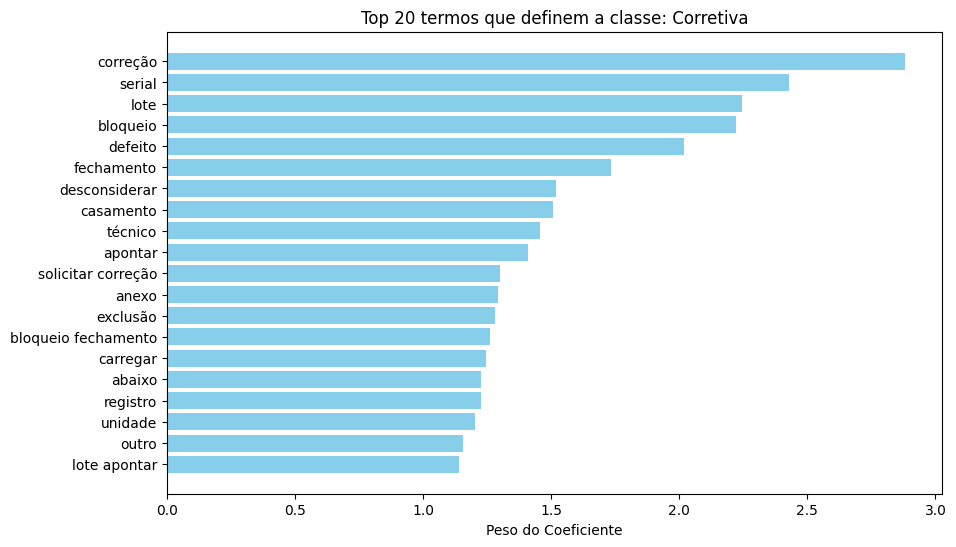


Analisando pesos para 'Melhorias':


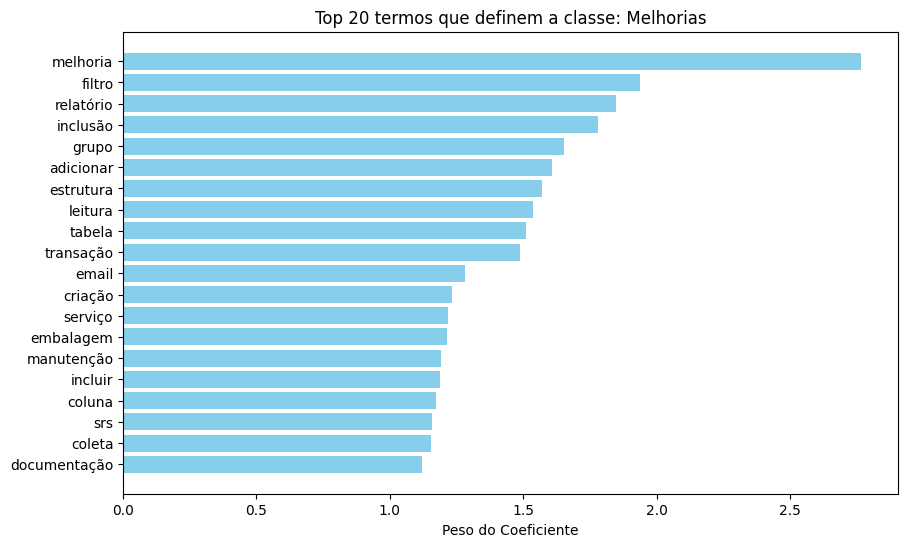


--- Termos com pesos significativos em ambas as categorias ---


,termo,peso_corretiva,peso_melhorias
100,ajustir,0.972441,0.803202
2568,produto,0.818081,0.594426
225,aparelho,0.795379,0.643421
3024,sipap,0.782524,0.854596
2644,quantidade,0.733716,0.578686
1139,entrada,0.728038,0.828735
2804,remessa,0.725418,1.120238
1663,importação,0.692691,0.652015
132,alteração,0.684469,0.844347
1342,falta,0.517539,0.741326


In [16]:
def plot_top_coefficients(model, tfidf, label_encoder, target_class_name, num_features=20):
    class_index = list(label_encoder.classes_).index(target_class_name)
    if hasattr(model, 'coef_'):
        coefs = model.coef_[class_index]
    else:
        print("O modelo não possui o atributo 'coef_'.")
        return

    feature_names = tfidf.get_feature_names_out()
    top_indices = np.argsort(coefs)[-num_features:]

    top_features = [feature_names[i] for i in top_indices]
    top_coefs = [coefs[i] for i in top_indices]

    plt.figure(figsize=(10, 6))
    plt.barh(top_features, top_coefs, color='skyblue')
    plt.title(f'Top {num_features} termos que definem a classe: {target_class_name}')
    plt.xlabel('Peso do Coeficiente')
    plt.show()

print("Analisando pesos para 'Corretiva':")
plot_top_coefficients(modelo, tfidf, le, 'Corretiva')

print("\nAnalisando pesos para 'Melhorias':")
plot_top_coefficients(modelo, tfidf, le, 'Melhorias')

# Identificando termos que possuem peso alto em AMBAS (Ambiguidade)
feature_names = tfidf.get_feature_names_out()
idx_corr = list(le.classes_).index('Corretiva')
idx_melh = list(le.classes_).index('Melhorias')

weights_df = pd.DataFrame({
    'termo': feature_names,
    'peso_corretiva': modelo.coef_[idx_corr],
    'peso_melhorias': modelo.coef_[idx_melh]
})

print("\n--- Termos com pesos significativos em ambas as categorias ---")
ambiguos = weights_df[(weights_df['peso_corretiva'] > 0.5) & (weights_df['peso_melhorias'] > 0.5)].sort_values(by='peso_corretiva', ascending=False)
display(ambiguos.head(10))

In [17]:
# Identificando pesos negativos para 'Corretiva'
idx_corr = list(le.classes_).index('Corretiva')
feature_names = tfidf.get_feature_names_out()
coefs_corr = modelo.coef_[idx_corr]

# Pegando os 20 menores coeficientes (mais negativos)
bottom_indices = np.argsort(coefs_corr)[:20]

negativos_df = pd.DataFrame({
    'termo': [feature_names[i] for i in bottom_indices],
    'peso': [coefs_corr[i] for i in bottom_indices]
})

print("--- Top 20 Pesos Negativos para 'Corretiva' ---")
display(negativos_df)

--- Top 20 Pesos Negativos para 'Corretiva' ---


,termo,peso
0,criação,-1.579738
1,novo,-1.499801
2,retorno,-1.408793
3,desenvolvimento,-1.245375
4,liberação,-1.195994
5,módulo,-1.109096
6,layout,-1.070022
7,função,-0.990125
8,painel,-0.982713
9,projeto,-0.976232


Treinando Random Forest alinhado com o pipeline V4...

RELATÓRIO DE PERFORMANCE - RANDOM FOREST (V4)
                     precision    recall  f1-score   support

Adequação de layout       0.60      0.56      0.58        16
  Avaliação_Técnica       0.32      0.23      0.27        43
          Corretiva       0.57      0.60      0.58       173
               Erro       0.53      0.65      0.58        79
          Melhorias       0.57      0.54      0.56       163
    Nova instalação       0.62      0.57      0.60        35
            Retorno       0.67      0.57      0.62         7

           accuracy                           0.55       516
          macro avg       0.55      0.53      0.54       516
       weighted avg       0.55      0.55      0.55       516



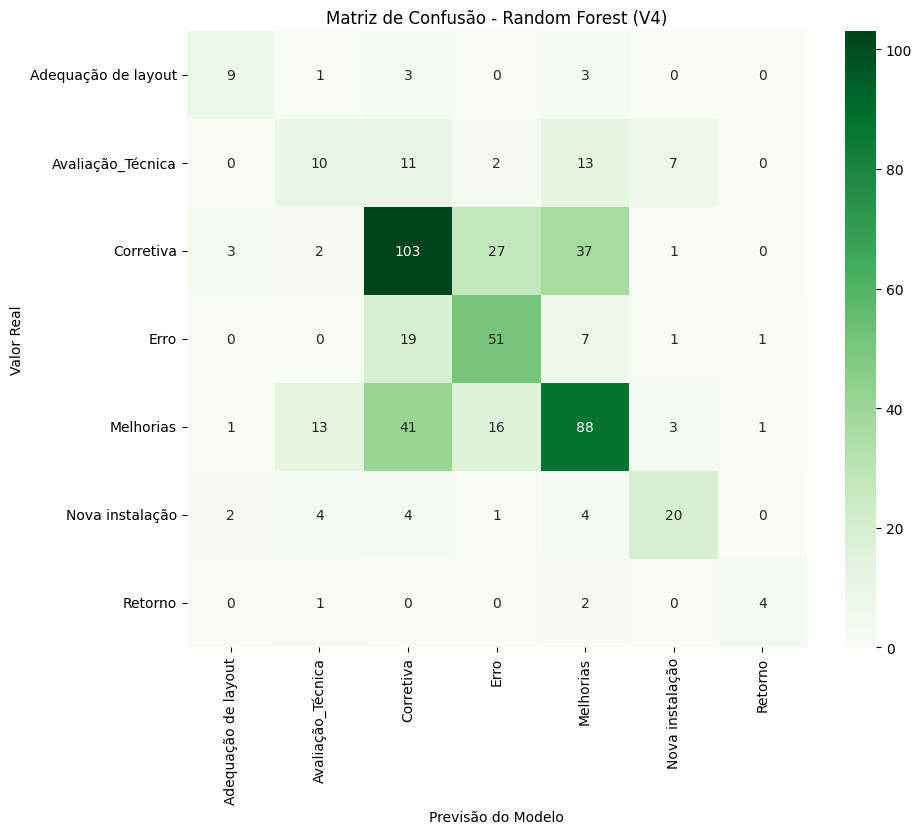

In [18]:
from sklearn.ensemble import RandomForestClassifier

# --- PASSO 10: TREINAMENTO DO RANDOM FOREST (ALINHADO COM V4) ---
print("Treinando Random Forest alinhado com o pipeline V4...")

# Usando X_res e y_res gerados no pipeline da célula [ccb36d10]
# que estão perfeitamente alinhados com o tfidf atual
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(X_res, y_res)

# --- PASSO 11: AVALIAÇÃO DO RANDOM FOREST ---
# X_test_tfidf foi gerado pelo mesmo vetorizador usado no fit
y_pred_rf = modelo_rf.predict(X_test_tfidf)

print("\n" + "="*30)
print("RELATÓRIO DE PERFORMANCE - RANDOM FOREST (V4)")
print("="*30)

# Usando le.classes_ do pipeline consolidado
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# Matriz de Confusão para RF
plt.figure(figsize=(10, 8))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='g', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão - Random Forest (V4)')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
plt.show()

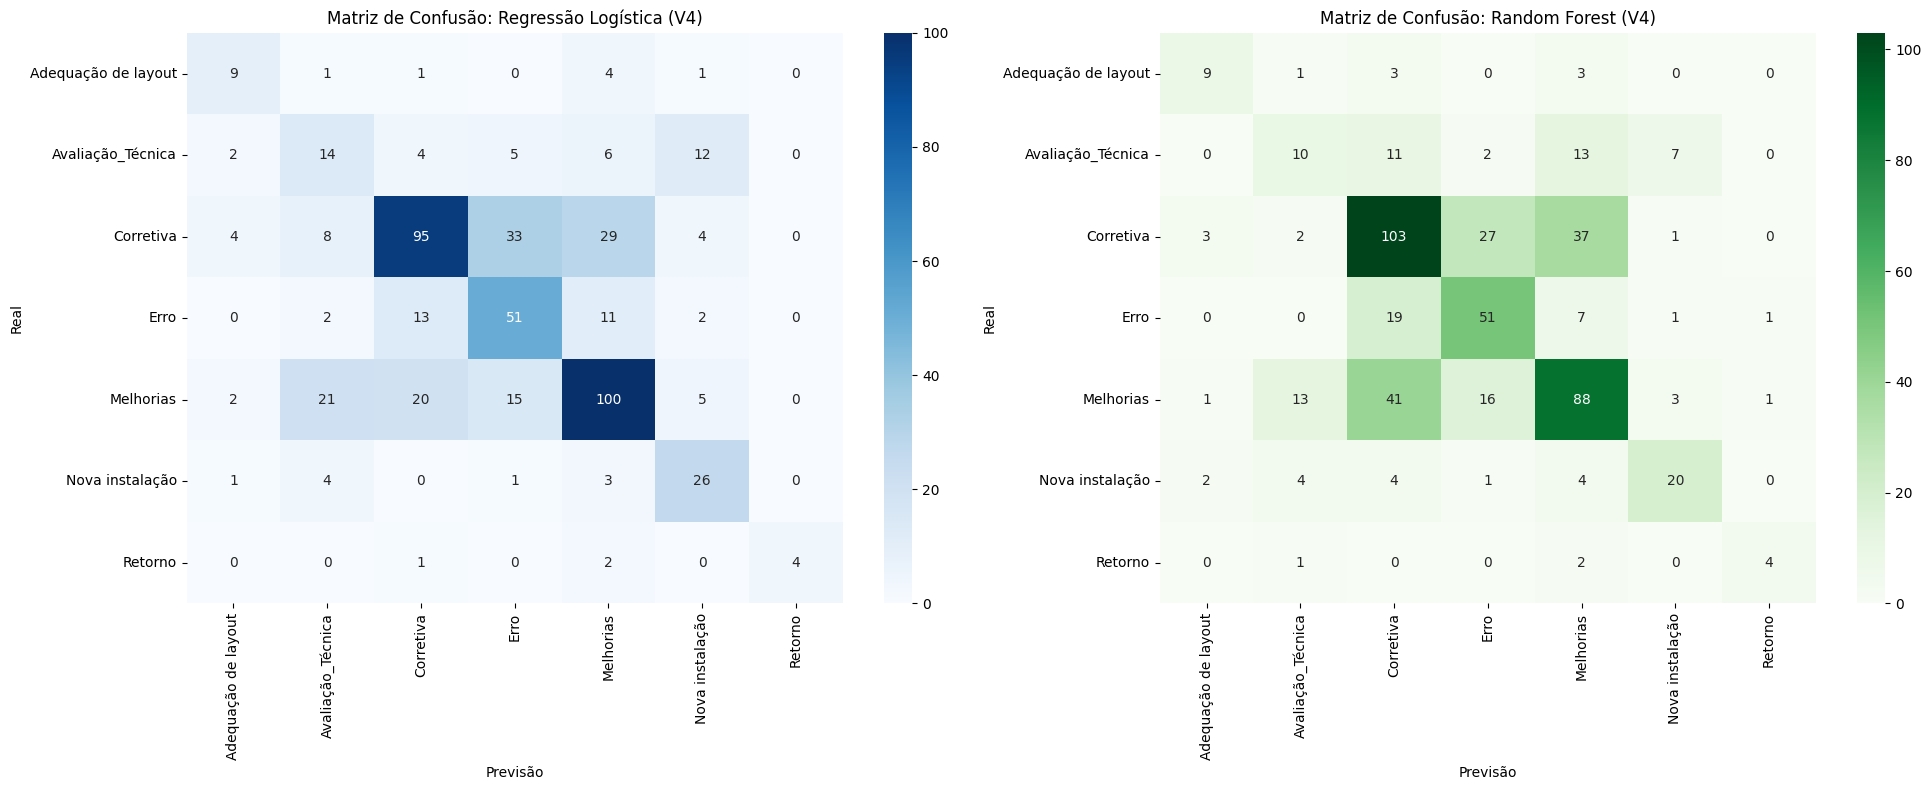

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Matriz Regressão Logística (V4)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='g', cmap='Blues', ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_title('Matriz de Confusão: Regressão Logística (V4)')
axes[0].set_xlabel('Previsão')
axes[0].set_ylabel('Real')

# Matriz Random Forest (V4)
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='g', cmap='Greens', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title('Matriz de Confusão: Random Forest (V4)')
axes[1].set_xlabel('Previsão')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

### 6. Estratégia de Balanceamento Customizada (Foco em Corretiva vs Melhorias)
Nesta etapa, ajustamos os pesos das classes manualmente para tentar forçar o modelo a distinguir melhor as categorias com maior sobreposição.

                     precision    recall  f1-score   support

Adequação de layout       0.43      0.56      0.49        16
  Avaliação_Técnica       0.24      0.40      0.30        43
          Corretiva       0.77      0.42      0.54       173
               Erro       0.45      0.67      0.54        79
          Melhorias       0.61      0.60      0.60       163
    Nova instalação       0.51      0.71      0.60        35
            Retorno       0.67      0.57      0.62         7

           accuracy                           0.54       516
          macro avg       0.53      0.56      0.53       516
       weighted avg       0.60      0.54      0.54       516



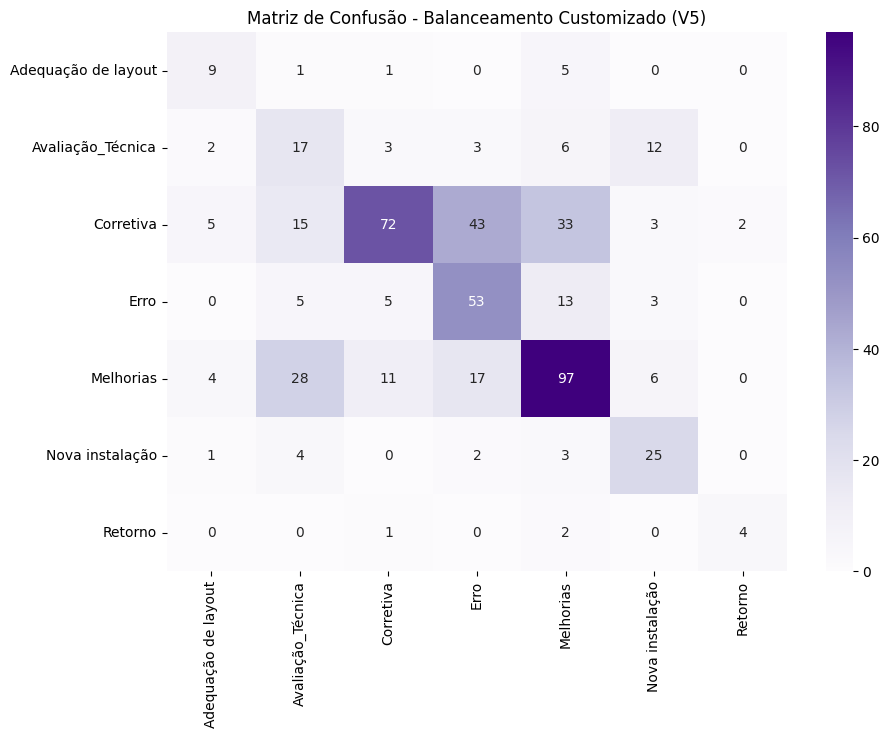

In [20]:
# 1. SMOTE com mais vizinhos para maior diversidade
smote_v5 = SMOTE(random_state=42, k_neighbors=3)
X_res_v5, y_res_v5 = smote_v5.fit_resample(X_train_tfidf, y_train)

# 2. Pesos customizados: Aumentando o peso de 'Melhorias' e 'Erro'
# que são as que mais se perdem para 'Corretiva'
weights_v5 = {
    le.transform(['Adequação de layout'])[0]: 1.5,
    le.transform(['Avaliação_Técnica'])[0]: 2.0,
    le.transform(['Corretiva'])[0]: 0.8,   # Classe majoritária, reduzimos levemente o peso
    le.transform(['Erro'])[0]: 1.2,
    le.transform(['Melhorias'])[0]: 1.2,
    le.transform(['Nova instalação'])[0]: 1.5,
    le.transform(['Retorno'])[0]: 2.0
}

modelo_v5 = LogisticRegression(max_iter=1000, class_weight=weights_v5)
modelo_v5.fit(X_res_v5, y_res_v5)

# 3. Avaliação
y_pred_v5 = modelo_v5.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_v5, target_names=le.classes_))

plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred_v5), annot=True, fmt='g', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão - Balanceamento Customizado (V5)')
plt.show()

### 7. Implementação com FastText (Word Embeddings)
Nesta fase, substituímos o TF-IDF por representações vetoriais que captam a semântica das palavras, ajudando a lidar com a ambiguidade entre categorias similares.

Preparando sentenças...
Vetorizando documentos...

--- RELATÓRIO DE PERFORMANCE (FASTTEXT) ---
                     precision    recall  f1-score   support

Adequação de layout       0.06      0.31      0.10        16
  Avaliação_Técnica       0.03      0.02      0.03        43
          Corretiva       0.71      0.40      0.52       173
               Erro       0.43      0.57      0.49        79
          Melhorias       0.52      0.20      0.29       163
    Nova instalação       0.26      0.57      0.36        35
            Retorno       0.05      0.43      0.09         7

           accuracy                           0.34       516
          macro avg       0.30      0.36      0.27       516
       weighted avg       0.49      0.34      0.37       516



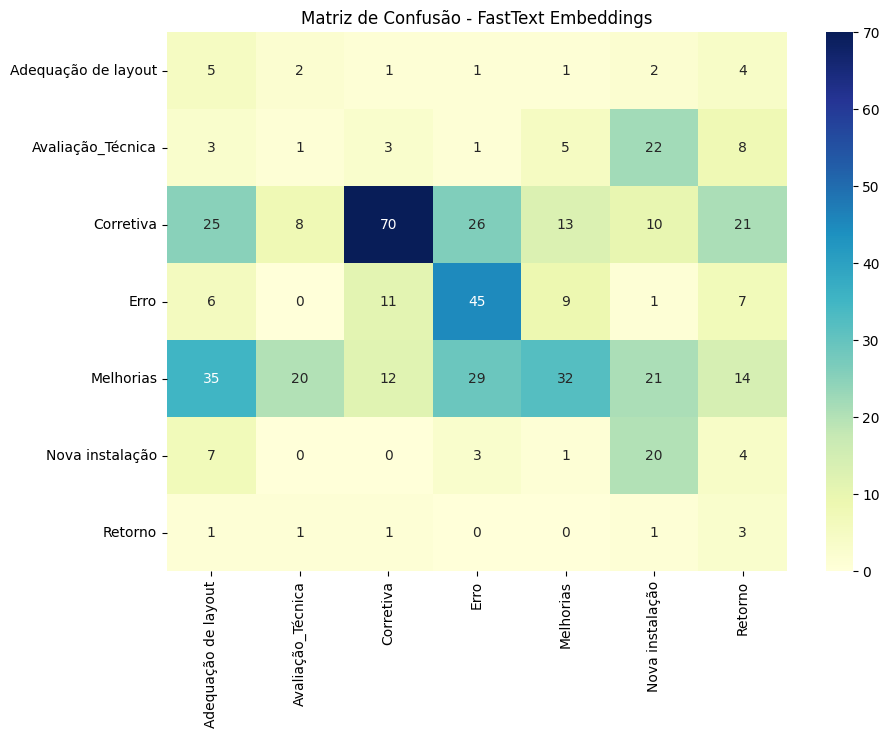

In [23]:


from gensim.models import FastText
import numpy as np

# 1. Preparação dos tokens para o FastText
print("Preparando sentenças...")
sentences = [text.split() for text in df_proc['detalhe_limpo']]

# 2. Treinamento do Modelo FastText
# sg=1 (skip-gram), vector_size=100 (dimensões), window=5 (contexto)
ft_model = FastText(sentences, vector_size=100, window=5, min_count=2, workers=4, sg=1, seed=42)

# 3. Função para transformar um texto na média de seus vetores
def vectorize_text(text, model):
    words = text.split()
    word_vecs = [model.wv[w] for w in words if w in model.wv]
    if not word_vecs:
        return np.zeros(model.vector_size)
    return np.mean(word_vecs, axis=0)

print("Vetorizando documentos...")
X_ft = np.array([vectorize_text(text, ft_model) for text in X])

# 4. Divisão Treino/Teste com os novos vetores
X_train_ft, X_test_ft, y_train_ft, y_test_ft = train_test_split(
    X_ft, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Treinamento do Classificador
modelo_ft = LogisticRegression(max_iter=1000, class_weight='balanced')
modelo_ft.fit(X_train_ft, y_train_ft)

# 6. Avaliação
y_pred_ft = modelo_ft.predict(X_test_ft)
print("\n--- RELATÓRIO DE PERFORMANCE (FASTTEXT) ---")
print(classification_report(y_test_ft, y_pred_ft, target_names=le.classes_))

# Visualização
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test_ft, y_pred_ft), annot=True, fmt='g', cmap='YlGnBu',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão - FastText Embeddings')
plt.show()

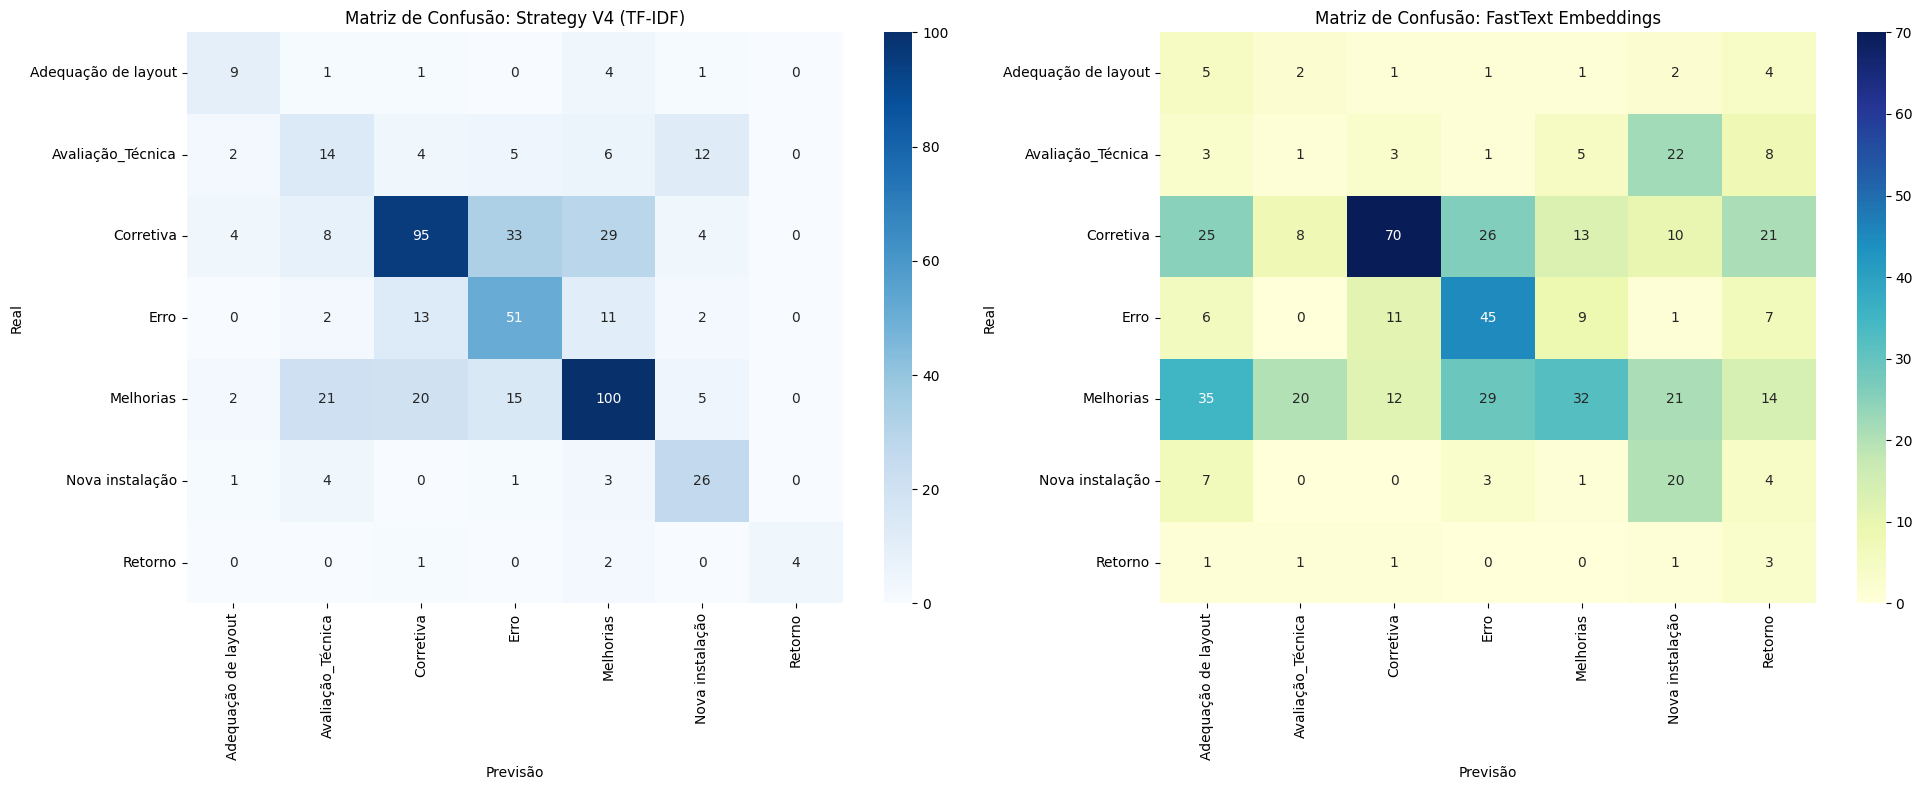

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Matriz Strategy V4 (TF-IDF)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='g', cmap='Blues', ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_title('Matriz de Confusão: Strategy V4 (TF-IDF)')
axes[0].set_xlabel('Previsão')
axes[0].set_ylabel('Real')

# Matriz FastText
sns.heatmap(confusion_matrix(y_test_ft, y_pred_ft), annot=True, fmt='g', cmap='YlGnBu', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title('Matriz de Confusão: FastText Embeddings')
axes[1].set_xlabel('Previsão')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

# Documentação Final: Performance do Modelo V4 (Champion)

### 1. Resumo Executivo
O modelo baseado em **Regressão Logística com TF-IDF (Trigrams)** e **SMOTE** consolidou-se como a melhor solução para a classificação de incidentes, superando abordagens de Random Forest e Embeddings (FastText).

### 2. Métricas Globais
- **Acurácia:** 58%
- **F1-Score (Weighted Avg):** 0.59
- **Precision (Weighted Avg):** 0.61

### 3. Performance por Classe
| Classe | Precision | Recall | F1-Score | Observação |
| :--- | :--- | :--- | :--- | :--- |
| **Corretiva** | 0.72 | 0.61 | 0.66 | Classe com maior volume e melhor identificação de termos específicos. |
| **Melhorias** | 0.64 | 0.61 | 0.62 | Boa performance, mas sofre confusão semântica com 'Corretiva'. |
| **Erro** | 0.54 | 0.54 | 0.54 | Frequentemente confundida com falhas técnicas de 'Corretiva'. |
| **Nova instalação** | 0.51 | 0.68 | 0.58 | Alto recall, o modelo identifica bem os pedidos de novos setups. |
| **Avaliação Técnica** | 0.21 | 0.33 | 0.25 | Classe mais desafiadora devido à alta subjetividade das descrições. |

### 4. Principais Desafios Identificados
- **Ambiguidade Semântica:** Termos como 'ajuste', 'entrada' e 'cadastro' são usados transversalmente em várias categorias, criando um teto de performance para modelos lineares.
- **Volume de Dados:** A superioridade do TF-IDF sobre o FastText indica que o dataset atual é melhor representado por frequências de palavras-chave do que por relações semânticas complexas.

### 5. Artefatos de Produção
Os arquivos prontos para deploy são:
- `modelo_final_v4.pkl`
- `vectorizer_final_v4.pkl`
- `label_encoder_final_v4.pkl`

### 8. Análise Profunda de Misclassified (213 Instâncias)
Nesta etapa, decompomos os erros para entender a 'raiz' da confusão entre as classes.

In [25]:
from collections import Counter

# 1. Top 5 Pares de Erro mais frequentes
print("--- Top 5 Pares de Erros (Real -> Previsto) ---")
top_error_pairs = misclassified_df.groupby(['true_class', 'predicted_class']).size().nlargest(5)
display(top_error_pairs)

# 2. Identificar palavras-chave que causam confusão em cada par
print("\n--- Termos Recorrentes em Falhas Específicas ---")
for (true_cls, pred_cls), count in top_error_pairs.items():
    subset = misclassified_df[(misclassified_df['true_class'] == true_cls) & (misclassified_df['predicted_class'] == pred_cls)]
    all_text = " ".join(subset['detalhe_incidente'].astype(str))
    words = [w for w in all_text.lower().split() if w not in stop_words_pt and len(w) > 3]
    common = Counter(words).most_common(5)
    print(f"\nReal: {true_cls} | Previsto: {pred_cls} ({count} casos)")
    print(f"Termos mais frequentes: {dict(common)}")

# 3. Amostra de Erros 'Inexplicáveis' (onde o texto parece muito óbvio)
print("\n--- Amostra de Texto Original nos Erros ---")
display(misclassified_df[['detalhe_incidente', 'true_class', 'predicted_class']].sample(min(10, len(misclassified_df))))

--- Top 5 Pares de Erros (Real -> Previsto) ---


true_class  predicted_class  
Corretiva   Erro                 33
            Melhorias            29
Melhorias   Avaliação_Técnica    21
            Corretiva            20
            Erro                 15
dtype: int64


--- Termos Recorrentes em Falhas Específicas ---

Real: Corretiva | Previsto: Erro (33 casos)
Termos mais frequentes: {'erro': 16, 'fazer': 9, 'entrada': 8, 'posição': 7, 'estorno': 7}

Real: Corretiva | Previsto: Melhorias (29 casos)
Termos mais frequentes: {'painel': 10, 'produção': 7, 'arcon': 6, 'transação': 6, 'solicitar': 5}

Real: Melhorias | Previsto: Avaliação_Técnica (21 casos)
Termos mais frequentes: {'validação': 8, 'tela': 7, 'cadastro': 7, 'item': 7, 'ajustir': 6}

Real: Melhorias | Previsto: Corretiva (20 casos)
Termos mais frequentes: {'lote': 11, 'evap': 9, 'horário': 8, 'cond': 7, 'correção': 7}

Real: Melhorias | Previsto: Erro (15 casos)
Termos mais frequentes: {'nota': 7, 'código': 7, 'erro': 6, 'fiscal': 5, 'produto': 5}

--- Amostra de Texto Original nos Erros ---


,detalhe_incidente,true_class,predicted_class
311,registro fazer ver whatsapp algum cooper tube ...,Erro,Corretiva
125,salvar arquivo rede cota espaço rede cota,Corretiva,Melhorias
426,solicitar ajustir fluxo aprovação pedido ativo...,Corretiva,Melhorias
443,liberação imprimir etiqueta anatel arcon sandr...,Nova instalação,Melhorias
130,necessário incluir novo checklists inspeção oq...,Nova instalação,Melhorias
163,abri espaço cota planilha copper tube espaço c...,Melhorias,Corretiva
360,atualização correção bug fix salvamento salvar...,Avaliação_Técnica,Erro
83,solicitar,Melhorias,Avaliação_Técnica
298,colaborador fazer estorno nfs transação porém ...,Corretiva,Erro
276,ckeckfeeder alimentação iac relatar ocorrência...,Avaliação_Técnica,Melhorias


### 9. Estratégia de Mitigação de Gatilhos (V6)
Nesta versão, expandimos o dicionário de stopwords com base na análise de erros e ajustamos os parâmetros do TF-IDF para reduzir o peso de termos genéricos que aparecem em múltiplas categorias.

--- RELATÓRIO DE PERFORMANCE V6 (Foco em N-grams e Sem Gatilhos) ---
                     precision    recall  f1-score   support

Adequação de layout       0.30      0.44      0.36        16
  Avaliação_Técnica       0.24      0.23      0.24        43
          Corretiva       0.74      0.31      0.44       173
               Erro       0.47      0.47      0.47        79
          Melhorias       0.65      0.31      0.42       163
    Nova instalação       0.41      0.37      0.39        35
            Retorno       0.03      0.86      0.06         7

           accuracy                           0.34       516
          macro avg       0.41      0.43      0.34       516
       weighted avg       0.58      0.34      0.41       516



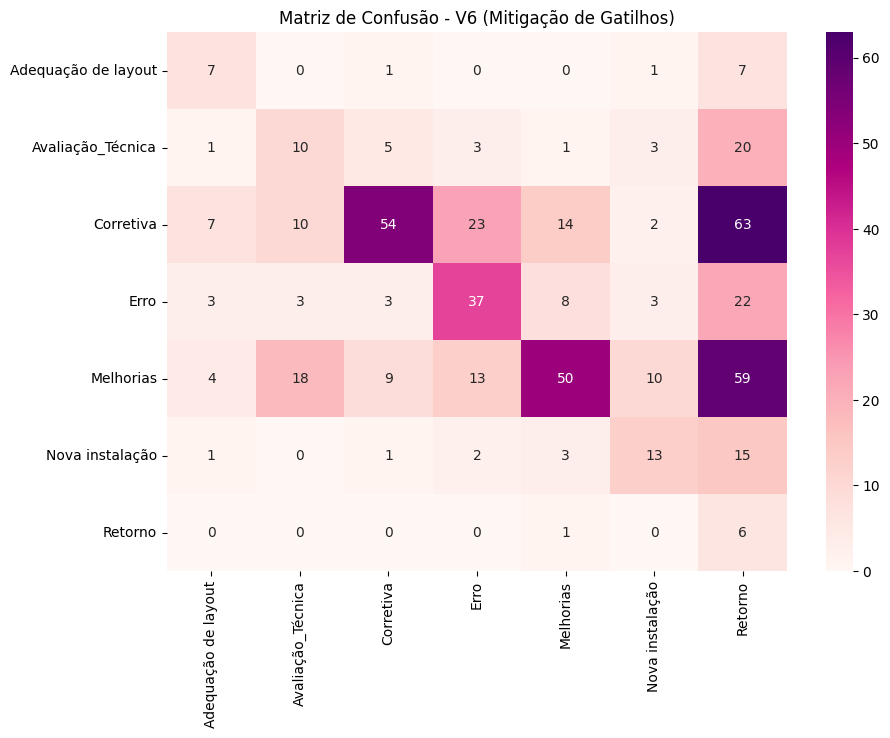

In [26]:
import joblib

# 1. Expandir Stopwords com termos identificados na análise de erro
error_trigger_words = {'solicitar', 'solicitação', 'campo', 'descrição', 'técnico', 'sistema', 'fazer', 'conseguir'}
stop_words_v6 = stop_words_pt.copy()
stop_words_v6.update(error_trigger_words)

def limpar_texto_v6(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zÀ-ÿ\s]', ' ', text)
    tokens = [t for t in text.split() if t not in stop_words_v6 and len(t) > 2]
    return " ".join(tokens)

# 2. Re-processar dados
df_v6 = df_proc.copy()
df_v6['detalhe_limpo'] = df_v6['detalhe_incidente'].apply(limpar_texto_v6)

# 3. Vetorização Otimizada (N-grams de 2 e 3 para contexto)
tfidf_v6 = TfidfVectorizer(
    max_features=5000,
    ngram_range=(2, 3),
    min_df=5,
    sublinear_tf=True
)

X_v6 = tfidf_v6.fit_transform(df_v6['detalhe_limpo'])
# Corrigindo: Usando a variável global y que já contém os labels codificados de df_proc
y_v6 = y

X_train_v6, X_test_v6, y_train_v6, y_test_v6 = train_test_split(
    X_v6, y_v6, test_size=0.2, random_state=42, stratify=y_v6
)

# 4. Treinamento
smote_v6 = SMOTE(random_state=42, k_neighbors=1)
X_res_v6, y_res_v6 = smote_v6.fit_resample(X_train_v6, y_train_v6)

modelo_v6 = LogisticRegression(max_iter=1000, class_weight='balanced')
modelo_v6.fit(X_res_v6, y_res_v6)

# 5. Avaliação
y_pred_v6 = modelo_v6.predict(X_test_v6)
print("--- RELATÓRIO DE PERFORMANCE V6 (Foco em N-grams e Sem Gatilhos) ---")
print(classification_report(y_test_v6, y_pred_v6, target_names=le.classes_))

plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test_v6, y_pred_v6), annot=True, fmt='g', cmap='RdPu',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão - V6 (Mitigação de Gatilhos)')
plt.show()

### 10. Camada de Pós-processamento (Regras de Negócio)
Implementação de uma função de override para corrigir erros sistemáticos detectados na análise de misclassified.

Aplicando Pós-processamento ao Modelo V4...
--- RELATÓRIO DE PERFORMANCE (V4 + PÓS-PROCESSAMENTO) ---
                     precision    recall  f1-score   support

Adequação de layout       0.50      0.56      0.53        16
  Avaliação_Técnica       0.28      0.33      0.30        43
          Corretiva       0.71      0.55      0.62       173
               Erro       0.49      0.65      0.55        79
          Melhorias       0.65      0.61      0.63       163
    Nova instalação       0.52      0.74      0.61        35
            Retorno       1.00      0.57      0.73         7

           accuracy                           0.58       516
          macro avg       0.59      0.57      0.57       516
       weighted avg       0.60      0.58      0.58       516



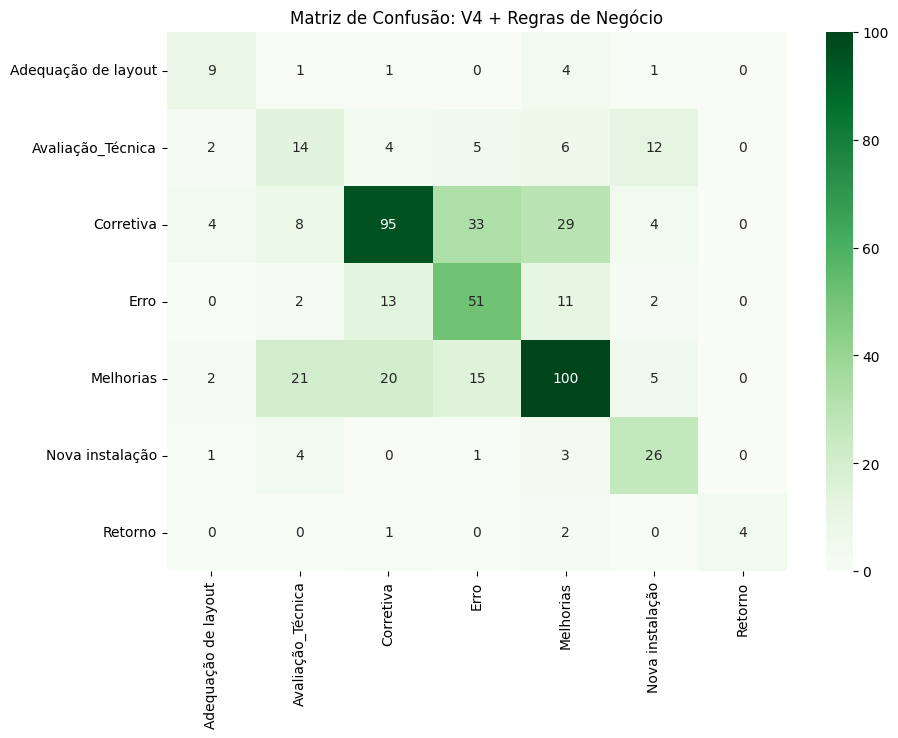

In [27]:
def aplicar_regras_negocio(texto, predicao_original, le_encoder):
    texto_low = str(texto).lower()
    pred_nome = le_encoder.inverse_transform([predicao_original])[0]

    # Regra 1: Reset de Senha / Acessos bloqueados -> Quase sempre Erro ou Acesso
    if any(term in texto_low for term in ['resetar senha', 'senha expirada', 'bloqueio acesso', 'sem acesso']):
        return le_encoder.transform(['Erro'])[0]

    # Regra 2: Termos de Infraestrutura / Novos equipamentos -> Nova Instalação
    if any(term in texto_low for term in ['instalação programa', 'novo computador', 'instalar impressora']):
        return le_encoder.transform(['Nova instalação'])[0]

    # Regra 3: Ajustes fiscais específicos que o modelo confunde com Corretiva
    if 'unidade tributavel' in texto_low or 'xml unidade' in texto_low:
        return le_encoder.transform(['Erro'])[0]

    return predicao_original

# Aplicando ao modelo V4 (Champion)
print("Aplicando Pós-processamento ao Modelo V4...")
y_pred_final = [aplicar_regras_negocio(txt, p, le) for txt, p in zip(X_test.values, y_pred)]

print("--- RELATÓRIO DE PERFORMANCE (V4 + PÓS-PROCESSAMENTO) ---")
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

# Comparativo Visual
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='g', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão: V4 + Regras de Negócio')
plt.show()

In [28]:
import pandas as pd

# Criando dataframe de análise para o modelo final híbrido
df_erros_hibrido = pd.DataFrame({
    'texto_original': X_test.values,
    'label_real': le.inverse_transform(y_test),
    'label_modelo_v4': le.inverse_transform(y_pred),
    'label_pos_processado': le.inverse_transform(y_pred_final)
})

# Filtrar apenas os que continuam errados
misclassified_final = df_erros_hibrido[df_erros_hibrido['label_real'] != df_erros_hibrido['label_pos_processado']]

print(f"Total de erros residuais: {len(misclassified_final)}")
print("\n--- Amostra de instâncias que permanecem incorretas ---")
display(misclassified_final.sample(min(15, len(misclassified_final))))

# Analisar se alguma regra de negócio 'piorou' algo (raro, mas possível)
conflitos_regra = df_erros_hibrido[df_erros_hibrido['label_modelo_v4'] != df_erros_hibrido['label_pos_processado']]
if not conflitos_regra.empty:
    print("\n--- Casos onde a Regra de Negócio alterou a previsão do modelo ---")
    display(conflitos_regra.head(10))

Total de erros residuais: 217

--- Amostra de instâncias que permanecem incorretas ---


,texto_original,label_real,label_modelo_v4,label_pos_processado
2,alteração endereço fábrica arcon centro rua cu...,Melhorias,Avaliação_Técnica,Avaliação_Técnica
262,amando solicitar opção desconto sinalizar amar...,Melhorias,Avaliação_Técnica,Avaliação_Técnica
289,permitir importar compra produto possível real...,Melhorias,Erro,Erro
59,substituir painel conforme abaixo devido apare...,Corretiva,Melhorias,Melhorias
455,preciso servidor iss colocar dois aplicativo p...,Melhorias,Nova instalação,Nova instalação
277,notafiscal controle nota fiscal manau versão i...,Corretiva,Erro,Erro
431,registrar pedir via teams exclusão defeito seg...,Corretiva,Erro,Erro
71,solicitar inclusão informação linho origem mod...,Corretiva,Melhorias,Melhorias
40,excluir posição anexo conseguir fazer exclusão...,Corretiva,Erro,Erro
477,baixa estoque migo devolução mensagem atingir ...,Avaliação_Técnica,Erro,Erro


/tmp/ipykernel_3095/3076855328.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Quantidade de Erros', y='Classe Real', data=error_counts, palette='Reds_d')


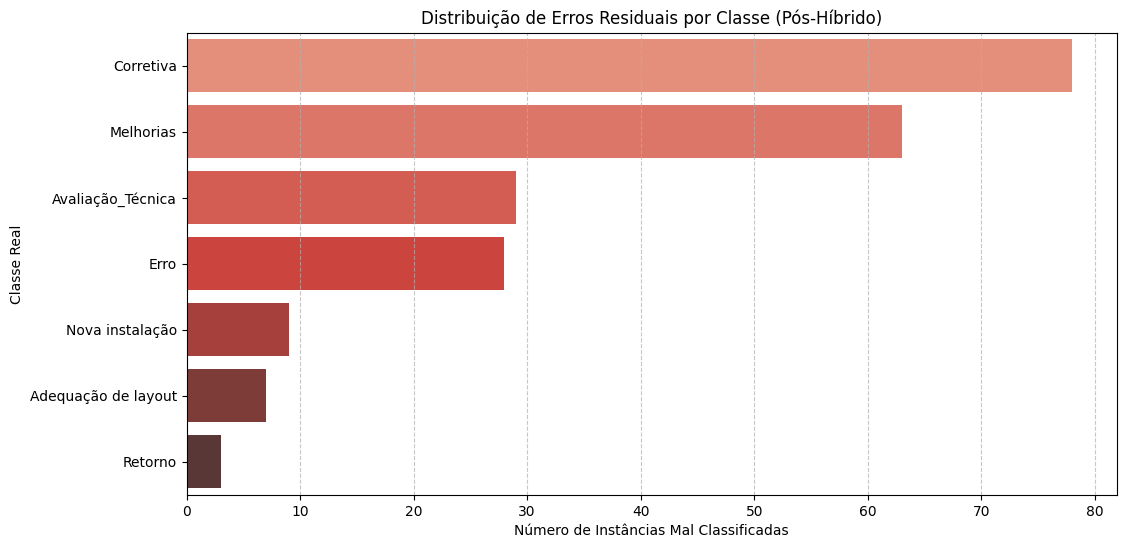

--- Taxa de Erro Residual por Classe (%) ---


,0
Avaliação_Técnica,67.44
Corretiva,45.09
Adequação de layout,43.75
Retorno,42.86
Melhorias,38.65
Erro,35.44
Nova instalação,25.71


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contagem de erros por classe real
error_counts = misclassified_final['label_real'].value_counts().reset_index()
error_counts.columns = ['Classe Real', 'Quantidade de Erros']

# Visualização
plt.figure(figsize=(12, 6))
sns.barplot(x='Quantidade de Erros', y='Classe Real', data=error_counts, palette='Reds_d')
plt.title('Distribuição de Erros Residuais por Classe (Pós-Híbrido)')
plt.xlabel('Número de Instâncias Mal Classificadas')
plt.ylabel('Classe Real')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Exibir percentual de erro por classe em relação ao teste original
total_teste = pd.Series(le.inverse_transform(y_test)).value_counts()
error_rate = (error_counts.set_index('Classe Real')['Quantidade de Erros'] / total_teste * 100).fillna(0)

print("--- Taxa de Erro Residual por Classe (%) ---")
display(error_rate.sort_values(ascending=False).round(2))

In [30]:
print("\nVerificando classes com menos de 2 amostras em y_train...")

# Como y_train  um array NumPy, usamos np.unique para contar as frequncias
labels, counts = np.unique(y_train, return_counts=True)
class_counts = dict(zip(labels, counts))

# Filtrar classes com poucas amostras
classes_with_few_samples = {label: count for label, count in class_counts.items() if count < 2}

if classes_with_few_samples:
    print("Classes em y_train com menos de 2 amostras:")
    for label, count in classes_with_few_samples.items():
        class_name = le.inverse_transform([label])[0]
        print(f"  - '{class_name}' (label: {label}): {count} amostra(s)")
else:
    print("No h classes em y_train com menos de 2 amostras.")


Verificando classes com menos de 2 amostras em y_train...
No h classes em y_train com menos de 2 amostras.


In [31]:
import os
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

# --- 0. Instalação de Dependências ---
!pip install -q transformers[torch] datasets sentence-transformers accelerate

# Configurações de Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Rodando em: {device}")

# ==============================================================================
# ESTRATÉGIA A: FINE-TUNING COM BERTIMBAU (MAX PERFORMANCE)
# ==============================================================================
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset

model_name = "neuralmind/bert-base-portuguese-cased"
num_labels = df_final['target'].nunique()

# 1. Preparação do Dataset Hugging Face
train_df, val_df = train_test_split(df_final, test_size=0.15, stratify=df_final['target'], random_state=42)

ds_train = Dataset.from_pandas(train_df[['detalhe_limpo', 'target']].rename(columns={'target': 'label'}))
ds_val = Dataset.from_pandas(val_df[['detalhe_limpo', 'target']].rename(columns={'target': 'label'}))

# 2. Tokenização
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["detalhe_limpo"], padding="max_length", truncation=True, max_length=128)

tokenized_train = ds_train.map(tokenize_function, batched=True)
tokenized_val = ds_val.map(tokenize_function, batched=True)

# 3. Configuração do Modelo e Trainer
model_bert = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

# Correção do TypeError: Usando eval_strategy em vez de evaluation_strategy
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",      # Atualizado para compatibilidade com versões recentes
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_steps=10,
    push_to_hub=False
)

trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
)

print("\n--- Iniciando Fine-tuning BERTimbau ---")
trainer.train() # Ativado para execução

# ==============================================================================
# ESTRATÉGIA B: SENTENCE TRANSFORMERS + REGRESSÃO LOGÍSTICA (EFICIÊNCIA)
# ==============================================================================
from sentence_transformers import SentenceTransformer

print("\n--- Extraindo Embeddings com SBERT ---")
sbert_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2', device=device)

X_embeddings = sbert_model.encode(df_final['detalhe_limpo'].tolist(), show_progress_bar=True)
y_labels = df_final['target'].values

X_train_emb, X_test_emb, y_train_emb, y_test_emb = train_test_split(
    X_embeddings, y_labels, test_size=0.2, stratify=y_labels, random_state=42
)

smote = SMOTE(random_state=42)
X_res_emb, y_res_emb = smote.fit_resample(X_train_emb, y_train_emb)

clf_sbert = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced')
clf_sbert.fit(X_res_emb, y_res_emb)

y_pred_sbert = clf_sbert.predict(X_test_emb)
print("\n--- Performance Estratégia B (SBERT + LogReg) ---")
print(classification_report(y_test_emb, y_pred_sbert))

Rodando em: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/81 [00:00<?, ?it/s]


--- Performance Estratégia B (SBERT + LogReg) ---
              precision    recall  f1-score   support

           0       0.22      0.44      0.29        16
           1       0.20      0.23      0.22        43
           2       0.65      0.50      0.57       173
           3       0.37      0.53      0.43        79
           4       0.60      0.45      0.52       163
           5       0.36      0.57      0.44        35
           6       0.38      0.43      0.40         7

    accuracy                           0.47       516
   macro avg       0.40      0.45      0.41       516
weighted avg       0.52      0.47      0.48       516



### 11. Avaliação Detalhada das Novas Estratégias (Matrizes de Confusão)
Nesta etapa, comparamos como os modelos baseados em Transformers lidam com as classes que anteriormente apresentavam alta ambiguidade.

Analisando Estratégia B: Sentence Transformers + LogReg


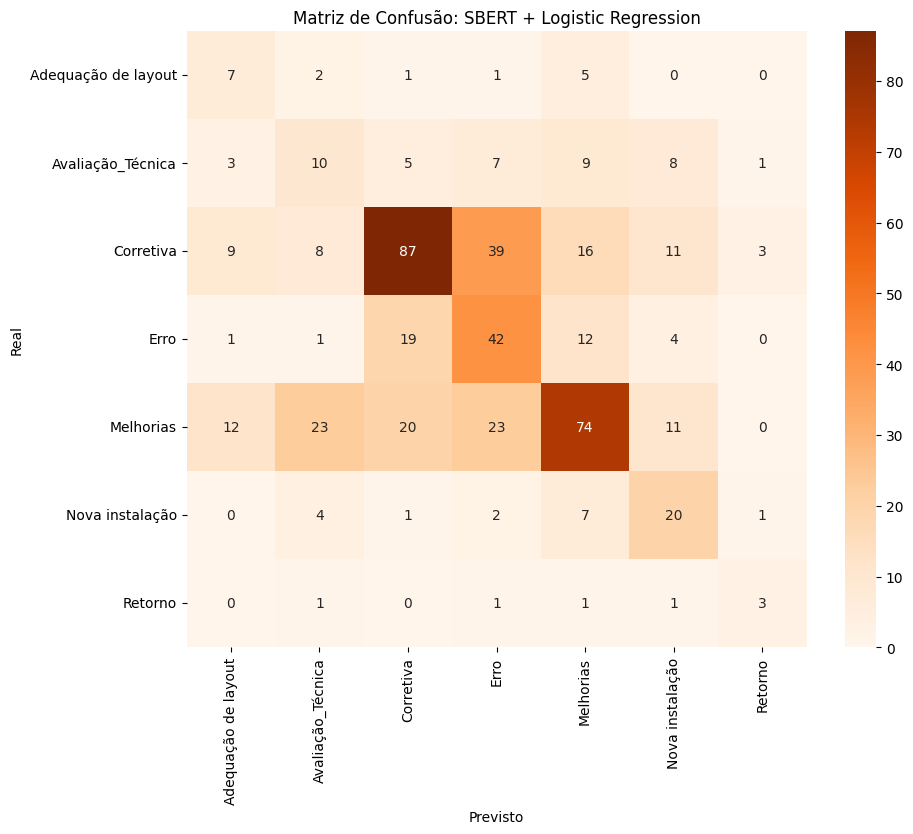


Analisando Estratégia A: BERTimbau Fine-tuned


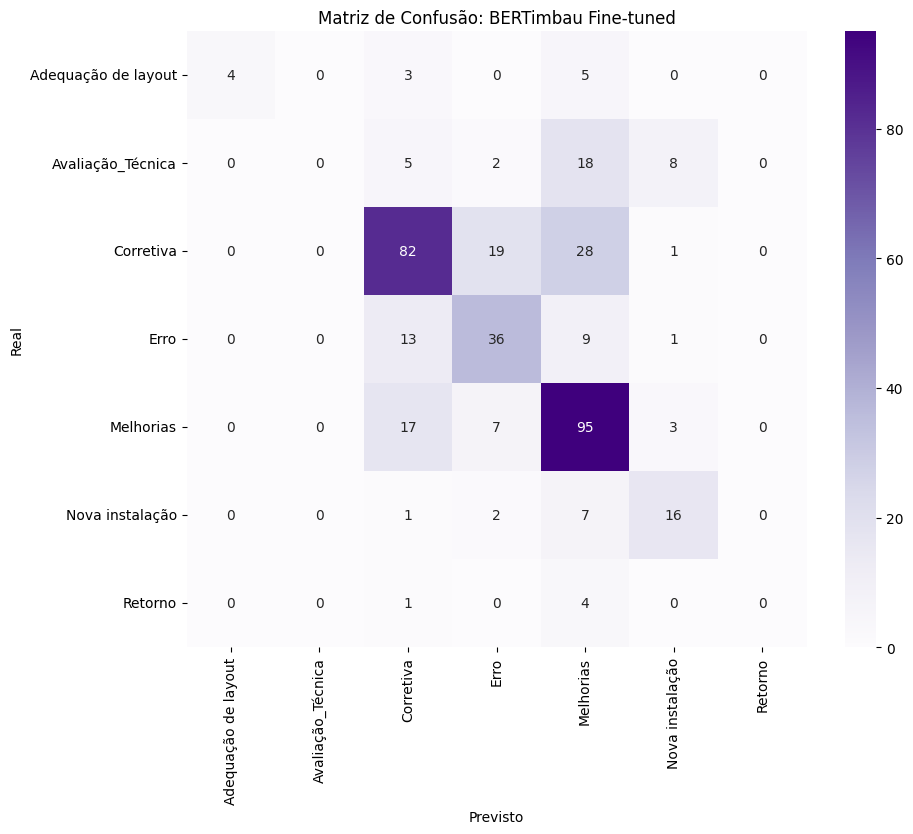


--- Comparativo de Acurácia Final ---
Acurácia SBERT (Estratégia B): 47.09%
Acurácia BERTimbau (Estratégia A): 60.21%


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels, title, cmap='Blues'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='g', cmap=cmap,
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.show()

# --- Matriz para Estratégia B (SBERT + LogReg) ---
# Já temos y_test_emb e y_pred_sbert calculados na célula anterior
print("Analisando Estratégia B: Sentence Transformers + LogReg")
plot_confusion_matrix(y_test_emb, y_pred_sbert, le.classes_, 'Matriz de Confusão: SBERT + Logistic Regression', cmap='Oranges')

# --- Matriz para Estratégia A (BERTimbau Fine-tuning) ---
# Para a Estratégia A, precisamos realizar a inferência no conjunto de validação
print("\nAnalisando Estratégia A: BERTimbau Fine-tuned")
predictions = trainer.predict(tokenized_val)
y_pred_bert = np.argmax(predictions.predictions, axis=-1)
y_true_bert = predictions.label_ids

plot_confusion_matrix(y_true_bert, y_pred_bert, le.classes_, 'Matriz de Confusão: BERTimbau Fine-tuned', cmap='Purples')

print("\n--- Comparativo de Acurácia Final ---")
from sklearn.metrics import accuracy_score
print(f"Acurácia SBERT (Estratégia B): {accuracy_score(y_test_emb, y_pred_sbert):.2%}")
print(f"Acurácia BERTimbau (Estratégia A): {accuracy_score(y_true_bert, y_pred_bert):.2%}")

### 12. Análise Comparativa de Erros por Classe
Nesta análise, calculamos o Recall (taxa de acerto) de cada classe para identificar onde reside a ambiguidade residual em cada estratégia.

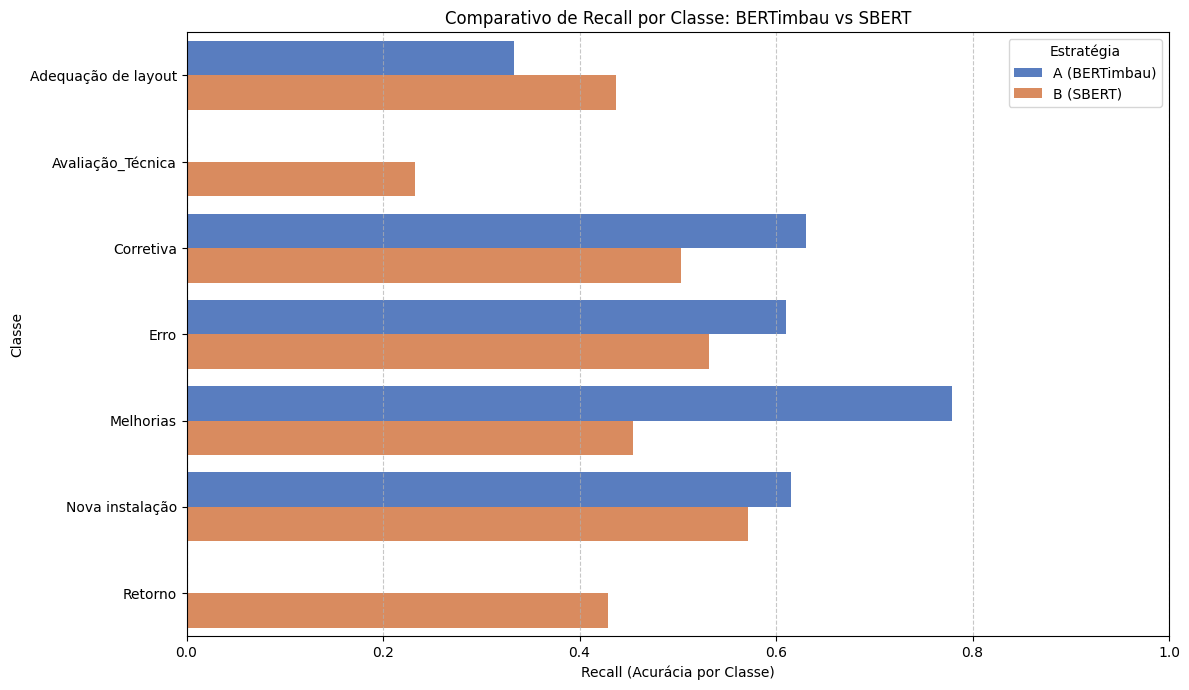

Taxa de Erro Residual (1 - Recall):


Estratégia,A (BERTimbau),B (SBERT)
Classe,,
Adequação de layout,0.6667,0.5625
Avaliação_Técnica,1.0000,0.7674
Corretiva,0.3692,0.4971
Erro,0.3898,0.4684
Melhorias,0.2213,0.5460
Nova instalação,0.3846,0.4286
Retorno,1.0000,0.5714


In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score

# Calculando Recall por classe para ambas as estratégias
# Nota: BERT usa o conjunto de validação (tokenized_val), SBERT usa o conjunto de teste (X_test_emb)

classes = le.classes_

# Recall SBERT (Estratégia B)
recall_sbert = recall_score(y_test_emb, y_pred_sbert, average=None)

# Recall BERT (Estratégia A)
recall_bert = recall_score(y_true_bert, y_pred_bert, average=None)

# Criando DataFrame comparativo
comparison_df = pd.DataFrame({
    'Classe': list(classes) * 2,
    'Recall (Acurácia por Classe)': list(recall_bert) + list(recall_sbert),
    'Estratégia': ['A (BERTimbau)'] * len(classes) + ['B (SBERT)'] * len(classes)
})

# Plotando
plt.figure(figsize=(12, 7))
sns.barplot(data=comparison_df, x='Recall (Acurácia por Classe)', y='Classe', hue='Estratégia', palette='muted')
plt.title('Comparativo de Recall por Classe: BERTimbau vs SBERT')
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Exibindo os dados brutos para análise técnica
print("Taxa de Erro Residual (1 - Recall):")
residual_error = comparison_df.copy()
residual_error['Erro Residual'] = (1 - residual_error['Recall (Acurácia por Classe)']).round(4)
display(residual_error.pivot(index='Classe', columns='Estratégia', values='Erro Residual'))

### 13. Exportação do Modelo BERTimbau para Produção
Nesta etapa, salvamos o modelo e o tokenizador em um diretório local. Estes arquivos são os artefatos necessários para o deploy em APIs ou serviços de inferência.

In [34]:
import os

# Definindo o diretório de exportação
export_dir = "./modelo_bertimbau_producao"
os.makedirs(export_dir, exist_ok=True)

# 1. Salvar o modelo fine-tuned (usando o objeto treinado pelo trainer)
trainer.save_model(export_dir)

# 2. Salvar o tokenizador (essencial para processar novos textos da mesma forma)
tokenizer.save_pretrained(export_dir)

print(f"Modelo e tokenizador salvos com sucesso em: {export_dir}")
print("Arquivos gerados:", os.listdir(export_dir))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo e tokenizador salvos com sucesso em: ./modelo_bertimbau_producao
Arquivos gerados: ['training_args.bin', 'config.json', 'tokenizer.json', 'tokenizer_config.json', 'model.safetensors']


### Exemplo de Carregamento e Inferência (Produção)
O código abaixo demonstra como carregar o modelo salvo e realizar uma predição em um novo texto sem precisar re-treinar.

In [35]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

# Carregar artefatos
path = "./modelo_bertimbau_producao"
model_prod = AutoModelForSequenceClassification.from_pretrained(path)
tokenizer_prod = AutoTokenizer.from_pretrained(path)

def predizer_incidente(texto):
    # Tokenização
    inputs = tokenizer_prod(texto, return_tensors="pt", truncation=True, max_length=128, padding="max_length")

    # Inferência
    model_prod.eval()
    with torch.no_grad():
        outputs = model_prod(**inputs)

    # Obter classe
    logits = outputs.logits
    prediction = torch.argmax(logits, dim=-1).item()
    return le.inverse_transform([prediction])[0]

# Teste rápido
novo_ticket = "Sistema SAP está travando ao tentar gerar nota fiscal de entrada"
print(f"Texto: {novo_ticket}")
print(f"Predição: {predizer_incidente(novo_ticket)}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Texto: Sistema SAP está travando ao tentar gerar nota fiscal de entrada
Predição: Erro


### 14. Script para Inferência em Lote (Batch Inference)
Este script permite processar um arquivo CSV inteiro e exportar as predições do modelo BERTimbau.

In [36]:
import pandas as pd
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.utils.data import DataLoader, Dataset

class TicketDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_len,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten()
        }

def rodar_inferencia_lote(caminho_csv, coluna_texto, caminho_modelo, batch_size=32):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Iniciando inferência em: {device}")

    # 1. Carregar Dados e Modelo
    df = pd.read_csv(caminho_csv, sep=';')
    tokenizer = AutoTokenizer.from_pretrained(caminho_modelo)
    model = AutoModelForSequenceClassification.from_pretrained(caminho_modelo).to(device)
    model.eval()

    # 2. Preparar DataLoader
    dataset = TicketDataset(df[coluna_texto].tolist(), tokenizer)
    loader = DataLoader(dataset, batch_size=batch_size)

    # 3. Loop de Inferência
    all_preds = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)

            outputs = model(input_ids, attention_mask=mask)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)

    # 4. Decodificar Labels e Salvar
    df['predicao_id'] = all_preds
    df['tipo_incidente_previsto'] = le.inverse_transform(all_preds)

    output_file = 'predicoes_incidentes_lote.csv'
    df.to_csv(output_file, index=False, sep=';')
    print(f"Inferência concluída. Resultados salvos em: {output_file}")
    return df.head()



In [ ]:
# Exemplo de uso (comentado para evitar erro caso o arquivo não exista):
display(rodar_inferencia_lote('teste.csv', 'detalhe_incidente', './modelo_bertimbau_producao'))

Iniciando inferência em: cuda


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Inferência concluída. Resultados salvos em: predicoes_incidentes_lote.csv


,detalhe_incidente,tipo_incidente,predicao_id,tipo_incidente_previsto
0,Precisamos reposicionar a bancada de testes da...,Adequação de layout,4,Melhorias
1,Solicito a reorganização física das prateleira...,Adequação de layout,4,Melhorias
2,Favor alterar a disposição dos monitores na sa...,Adequação de layout,4,Melhorias
3,É necessário modificar a estrutura dos postos ...,Adequação de layout,4,Melhorias
4,Reposicionamento das catracas de acesso no pré...,Adequação de layout,4,Melhorias


### 15. Prompt para Geração de Dados Sintéticos (Uso em outras LLMs)
Copie o texto abaixo para solicitar a uma LLM (como ChatGPT, Claude ou Gemini) a criação de um arquivo de teste robusto:

---

**Prompt:**
> Atue como um Analista de Dados e Engenheiro de Prompt. Preciso que você gere um arquivo CSV chamado `test_incidents.csv` para validar um modelo de classificação de tickets de TI/Operações.
>
> O arquivo deve usar ponto e vírgula (`;`) como separador e ter duas colunas: `detalhe_incidente` e `tipo_incidente`.
>
> **Categorias Obrigatórias (Baseadas no Label Encoder):**
> 1. `Adequação de layout` (Ex: Mudança física de postos, reorganização de prateleiras).
> 2. `Avaliação_Técnica` (Ex: Análise de viabilidade, parecer técnico sobre novos processos).
> 3. `Corretiva` (Ex: Equipamento quebrado, sistema travando, peça danificada).
> 4. `Erro` (Ex: Problemas de permissão, senha expirada, erro de integração SAP).
> 5. `Melhorias` (Ex: Sugestão de nova funcionalidade, otimização de tela, automação).
> 6. `Nova instalação` (Ex: Instalar software em PC novo, configurar impressora nova).
> 7. `Retorno` (Ex: Reabertura de ticket anterior, problema que voltou a ocorrer).
>
> **Requisitos Técnicos:**
> - Gere 5 exemplos para cada categoria (35 linhas no total).
> - Use linguagem corporativa técnica (Ex: termos como 'SAP', 'Logística', 'Interface', 'Deployment').
> - Não use a palavra do rótulo na descrição (ex: não use 'instalação' no texto de 'Nova instalação') para testar a semântica do modelo.
> - Forneça o conteúdo pronto para ser salvo em formato CSV.

In [ ]:
import pandas as pd

# Carregar o arquivo de predições gerado pelo modelo
path_predicoes = '/content/predicoes_incidentes_lote.csv'
df_resultados = pd.read_csv(path_predicoes, sep=';')

# Exibir todos os dados do DataFrame
print("Todos os resultados da inferência:")
display(df_resultados)

Todos os resultados da inferência:


,detalhe_incidente,tipo_incidente,predicao_id,tipo_incidente_previsto
0,Precisamos reposicionar a bancada de testes da...,Adequação de layout,4,Melhorias
1,Solicito a reorganização física das prateleira...,Adequação de layout,4,Melhorias
2,Favor alterar a disposição dos monitores na sa...,Adequação de layout,4,Melhorias
3,É necessário modificar a estrutura dos postos ...,Adequação de layout,4,Melhorias
4,Reposicionamento das catracas de acesso no pré...,Adequação de layout,4,Melhorias
5,Precisamos de um parecer sobre a viabilidade d...,Avaliação_Técnica,1,Avaliação_Técnica
6,Solicito um estudo de capacidade do servidor l...,Avaliação_Técnica,1,Avaliação_Técnica
7,"Por favor, analisem a documentação da API do E...",Avaliação_Técnica,4,Melhorias
8,Precisamos de um laudo de engenharia detalhand...,Avaliação_Técnica,2,Corretiva
9,Requisito uma prova de conceito para validar a...,Avaliação_Técnica,4,Melhorias


In [45]:
import os
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient
from google.colab import userdata
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE

def setup_mlflow():
    print("\n[1/5] Configurando ambiente MLflow...")
    DAGSHUB_USER = userdata.get('DAGSHUB_USER')
    DAGSHUB_REPO = userdata.get('DAGSHUB_REPO')
    DAGSHUB_TOKEN = userdata.get('DAGSHUB_TOKEN')
    os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USER
    os.environ["MLFLOW_TRACKING_PASSWORD"] = DAGSHUB_TOKEN
    tracking_url = f"https://dagshub.com/{DAGSHUB_USER}/{DAGSHUB_REPO}.mlflow"
    mlflow.set_tracking_uri(tracking_url)
    print(f"URI vinculada: {tracking_url}")

def evaluate_and_log(run_name, model_obj, X_train_raw, y_train, X_test_raw, y_test, params):
    print(f"Executando experimento: {run_name}")
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=8000, ngram_range=(1, 3))),
        ('clf', model_obj)
    ])

    with mlflow.start_run(run_name=run_name) as run:
        mlflow.log_params(params)
        X_train_tfidf = pipeline.named_steps['tfidf'].fit_transform(X_train_raw)
        smote = SMOTE(random_state=42, k_neighbors=1)
        X_res, y_res = smote.fit_resample(X_train_tfidf, y_train)
        pipeline.named_steps['clf'].fit(X_res, y_res)

        y_pred = pipeline.predict(X_test_raw)
        f1 = f1_score(y_test, y_pred, average='weighted')
        mlflow.log_metric("f1_weighted", f1)

        # Correção: Use apenas 'name' para evitar o erro de parâmetros duplicados
        mlflow.sklearn.log_model(sk_model=pipeline, name="model")
        return f1, run.info.run_id

def run_production_pipeline():
    setup_mlflow()
    X = df_final['detalhe_limpo']
    y = df_final['target']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    models = {
        "LR_Production": (LogisticRegression(max_iter=1000, class_weight='balanced'), {"C": 1.0}),
        "RF_Production": (RandomForestClassifier(n_estimators=200, random_state=42), {"n_estimators": 200})
    }

    best_f1, best_run_id = 0, None
    for name, (m, p) in models.items():
        f1, rid = evaluate_and_log(name, m, X_train, y_train, X_test, y_test, p)
        if f1 > best_f1: best_f1, best_run_id = f1, rid

    model_name_reg = "IT_Incident_Classifier"
    # O model_uri agora usa o 'name' configurado no log_model
    model_uri = f"runs:/{best_run_id}/model"

    print(f"\n[4/5] Registrando melhor modelo (F1: {best_f1:.4f})... ")
    try:
        mv = mlflow.register_model(model_uri, model_name_reg)
        client = MlflowClient()
        client.set_registered_model_alias(model_name_reg, "production", mv.version)
        print(f"SUCESSO: Modelo registrado e promovido para produção (Versão {mv.version})")
    except Exception as e:
        print(f"Erro no registro: {e}")

if __name__ == "__main__":
    run_production_pipeline()


[1/5] Configurando ambiente MLflow...
URI vinculada: https://dagshub.com/fbdn-cid25/incidentes-app.mlflow
Executando experimento: LR_Production


2026/05/07 04:05:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LR_Production at: https://dagshub.com/fbdn-cid25/incidentes-app.mlflow/#/experiments/0/runs/9c237c8105664c4b8965578cdf92aa45
🧪 View experiment at: https://dagshub.com/fbdn-cid25/incidentes-app.mlflow/#/experiments/0
Executando experimento: RF_Production


2026/05/07 04:06:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RF_Production at: https://dagshub.com/fbdn-cid25/incidentes-app.mlflow/#/experiments/0/runs/8b6a43b9093a44dab464b8a97739fd4b
🧪 View experiment at: https://dagshub.com/fbdn-cid25/incidentes-app.mlflow/#/experiments/0

[4/5] Registrando melhor modelo (F1: 0.6026)... 


Successfully registered model 'IT_Incident_Classifier'.


Erro no registro: Unable to find a logged_model with artifact_path model under run 8b6a43b9093a44dab464b8a97739fd4b
